# Fase 7 — eICU Inferencia y Metricas de Validacion Externa

Aplica los 5 modelos entrenados en MIMIC-IV-ED sobre la cohorte eICU sin reentrenar.
Evalúa AUROC, AUPRC y Brier score para L2 (mortalidad) y L3 (intervención crítica).

**Adaptaciones necesarias para eICU** (variables ausentes o con diferente distribución):

| Feature | MIMIC | eICU |
|---------|-------|------|
| `acuity` | ESI 1–5 | No existe: imputado con mediana MIMIC |
| `chiefcomplaint` | Texto libre | No existe: cadena vacía |
| `temperature` | <5% missing | ~95% missing: imputado |
| LSTM seq_len | media 2,11 | 1 (único snapshot disponible) |

La validación externa evalúa la capacidad de generalización de los modelos a una distribución de datos distinta (diferente hospital, diferente año, diferente severidad basal).

In [10]:
import logging, sys, json, pickle
from pathlib import Path

_root = Path.cwd()
while not (_root / 'CLAUDE.md').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s', force=True)
print(f'Raíz: {_root}')

Raíz: C:\Users\cuent\Documents\UAX\TFM\TFM


In [11]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf

PROCESSED  = _root / 'CodigoGit' / 'data' / 'processed'
MODELS_DIR = _root / 'CodigoGit' / 'models'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGETS    = ['L2', 'L3']

# Features numéricas (coincide con todos los modelos entrenados)
NUM_FEATURES = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
                'acuity', 'n_medications', 'pain']
VITAL_COLS   = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

LABELS = {'logreg': 'LogReg+LASSO', 'catboost': 'CatBoost',
          'lstm': 'LSTM', 'tabtransformer': 'TabTransformer', 'nam': 'NAM'}

print(f'Device: {DEVICE}')
print(f'PROCESSED: {PROCESSED}')
print(f'MODELS_DIR: {MODELS_DIR}')

Device: cuda
PROCESSED: C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\data\processed
MODELS_DIR: C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\models


## 1. Cargar datos

Se cargan los artefactos del pipeline MIMIC (train, vitales eICU, cohorte, etiquetas) y se ensambla el DataFrame de inferencia con las variables esperadas por cada modelo. Las variables ausentes en eICU (`acuity`, `chiefcomplaint`) se imputan con valores neutros.

In [12]:
df_train = pd.read_parquet(PROCESSED / 'train.parquet')
n_meds   = pd.read_parquet(PROCESSED / 'medrecon_nmeds.parquet')

df_train = df_train.merge(n_meds[['stay_id', 'n_medications']], on='stay_id', how='left')
df_train['n_medications'] = df_train['n_medications'].fillna(0).astype(float)
df_train['pain']          = pd.to_numeric(df_train['pain'], errors='coerce')
df_train['chiefcomplaint'] = df_train['chiefcomplaint'].fillna('').astype(str).str.lower().str.strip()

cohort = pd.read_parquet(PROCESSED / 'eicu_cohort.parquet')
vitals = pd.read_parquet(PROCESSED / 'eicu_vitals.parquet')
l3     = pd.read_parquet(PROCESSED / 'eicu_l3.parquet')

eicu = (cohort[['patientunitstayid', 'gender', 'ethnicity', 'L2']]
        .merge(vitals, on='patientunitstayid', how='left')
        .merge(l3,    on='patientunitstayid', how='left'))

# Variables ausentes en eICU: se imputan con valores neutros
eicu['acuity']            = np.nan          # ESI no existe en eICU
eicu['chiefcomplaint']    = ''              # motivo de consulta no disponible
eicu['pain']              = np.nan          # escala de dolor no disponible
eicu['n_medications']     = 0.0            # sin información de medicación previa
eicu['arrival_transport'] = 'UNKNOWN'      # modo de llegada no disponible

eicu_preds = eicu[['patientunitstayid', 'gender', 'ethnicity', 'L2', 'L3']].copy()

print(f'MIMIC train: {len(df_train):,} | eICU: {len(eicu):,}')
print(f'L2={eicu["L2"].mean():.3%} | L3={eicu["L3"].mean():.3%}')
print()
print('Missing vitales en eICU:')
for c in NUM_FEATURES:
    if c in eicu.columns:
        print(f'  {c:15s}: {eicu[c].isna().mean():.1%}')

MIMIC train: 278,320 | eICU: 89,594
L2=8.580% | L3=19.117%

Missing vitales en eICU:
  temperature    : 95.4%
  heartrate      : 11.4%
  resprate       : 19.9%
  o2sat          : 14.1%
  sbp            : 16.6%
  dbp            : 16.6%
  acuity         : 100.0%
  n_medications  : 0.0%
  pain           : 100.0%


## 2. LogReg + LASSO

Refit del preprocesador (imputer + scaler + TF-IDF) sobre el train MIMIC con los hiperparámetros óptimos almacenados en `best_params.json`. El campo `chiefcomplaint` vacío en eICU produce un vector TF-IDF de ceros, lo que equivale a no aportar información textual.

In [13]:
import joblib

LR_DIR = MODELS_DIR / 'logreg' / '20260609_211117'

# OHE re-ajustado sobre train (no serializado en pipeline)
ohe_lr = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
ohe_lr.fit(df_train[['arrival_transport']].fillna('desconocido'))

X_cat_tr_lr = ohe_lr.transform(df_train[['arrival_transport']].fillna('desconocido'))
# eICU: arrival_transport='UNKNOWN' — handle_unknown='ignore' produce vector cero
X_cat_te_lr = ohe_lr.transform(eicu[['arrival_transport']].fillna('desconocido'))

for t in TARGETS:
    pipe  = joblib.load(LR_DIR / f'pipeline_{t}.joblib')
    model = joblib.load(LR_DIR / f'logreg_{t}.joblib')

    X_num_tr = pipe['scaler'].transform(pipe['imputer'].transform(df_train[NUM_FEATURES]))
    X_num_te = pipe['scaler'].transform(pipe['imputer'].transform(eicu[NUM_FEATURES]))

    X_tfidf_tr = pipe['tfidf'].transform(df_train['chiefcomplaint'])
    X_tfidf_te = pipe['tfidf'].transform(eicu['chiefcomplaint'])  # vector cero (campo vacío)

    X_tr = sp.hstack([sp.csr_matrix(X_num_tr), X_cat_tr_lr, X_tfidf_tr]).tocsr()
    X_te = sp.hstack([sp.csr_matrix(X_num_te), X_cat_te_lr, X_tfidf_te]).tocsr()

    eicu_preds[f'logreg_{t}'] = model.predict_proba(X_te)[:, 1]
    print(f'  {t}: OK  (X_te shape={X_te.shape})')

  L2: OK  (X_te shape=(89594, 114))
  L3: OK  (X_te shape=(89594, 107))


## 3. CatBoost

Carga del modelo serializado en formato `.cbm`. CatBoost gestiona internamente los valores nulos y la feature categórica `chiefcomplaint` (cadena vacía en eICU), por lo que no requiere preprocesamiento adicional.

In [14]:
CB_DIR      = MODELS_DIR / 'catboost_optuna' / '20260609_224204'
CB_FEATURES = NUM_FEATURES + ['chiefcomplaint', 'arrival_transport']

for t in TARGETS:
    model = CatBoostClassifier()
    model.load_model(str(CB_DIR / f'catboost_{t}.cbm'))
    eicu_preds[f'catboost_{t}'] = model.predict_proba(eicu[CB_FEATURES])[:, 1]
    print(f'  {t}: OK')

  L2: OK
  L3: OK


## 4. LSTM (secuencia de longitud 1)

En eICU solo hay un snapshot de vitales por paciente, por lo que la secuencia tiene longitud 1. Se usa `pack_padded_sequence` con `lengths=[1]` para compatibilidad con la arquitectura entrenada sobre secuencias de longitud variable en MIMIC.

In [15]:
LSTM_DIR = MODELS_DIR / 'lstm' / '20260610_213549'
with open(LSTM_DIR / 'model_config.json') as f:
    lstm_cfg = json.load(f)
with open(LSTM_DIR / 'preprocessors.pkl', 'rb') as f:
    lstm_pre = pickle.load(f)

# Normalización de secuencias: re-ajustar sobre train (mismas columnas que entrenamiento)
imp_seq = SimpleImputer(strategy='median')
sc_seq  = StandardScaler()
sc_seq.fit(imp_seq.fit_transform(df_train[VITAL_COLS]))

raw_eicu = eicu[VITAL_COLS].values.astype(np.float32)
raw_imp  = imp_seq.transform(raw_eicu)
raw_sc   = sc_seq.transform(raw_imp).astype(np.float32)

# Construir secuencia de longitud 1 (único snapshot disponible en eICU)
max_len  = lstm_cfg['max_len']   # = 10
N        = len(eicu)
X_seq    = np.zeros((N, max_len, 6), dtype=np.float32)
X_seq[:, 0, :] = raw_sc          # snapshot en t=0; resto son ceros (enmascarados)

# Features estáticas: cc_encoded = oov (sin chiefcomplaint en eICU)
eicu_tmp = eicu.copy()
eicu_tmp['cc_encoded'] = float(lstm_cfg['cc_oov_idx'])

static_feats    = lstm_cfg['static_features']   # 10 cols incluyendo cc_encoded
X_static_imp    = lstm_pre['imputer'].transform(eicu_tmp[static_feats].values.astype(np.float32))
X_static_sc     = lstm_pre['scaler'].transform(X_static_imp)

# OHE arrival_transport: UNKNOWN es una categoría conocida → vector one-hot [0,0,0,1,0]
at_vals = eicu['arrival_transport'].fillna('UNKNOWN').str.upper().str.strip().values.reshape(-1, 1)
_at_raw = lstm_pre['ohe'].transform(at_vals)
X_at_ohe = (_at_raw.toarray() if hasattr(_at_raw, 'toarray') else _at_raw).astype(np.float32)

X_static = np.hstack([X_static_sc, X_at_ohe]).astype(np.float32)  # (N, 15)

for t in TARGETS:
    model = tf.keras.models.load_model(str(LSTM_DIR / f'lstm_{t}.keras'))
    probs = model.predict([X_seq, X_static], batch_size=2048, verbose=0)
    eicu_preds[f'lstm_{t}'] = probs.ravel()
    print(f'  {t}: OK')

C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
WARNING — TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


  L2: OK
  L3: OK


## 5. TabTransformer

Carga del modelo y los preprocesadores (scaler, imputer, vocabulario de chiefcomplaint). Las variables categóricas ausentes en eICU (`acuity`=0, `chiefcomplaint`=índice 0) activan el `padding_idx` del embedding, contribuyendo con el vector cero.

In [16]:
from pytorch_tabular import TabularModel

TT_DIR = MODELS_DIR / 'tabtransformer' / '20260611_085045'
with open(TT_DIR / 'model_config.json') as f:
    tt_cfg = json.load(f)
with open(TT_DIR / 'preprocessors.pkl', 'rb') as f:
    tt_pre = pickle.load(f)

cont_feats_tt = tt_cfg['cont_features']   # 8 features (sin acuity)
top_cc_set    = set(tt_cfg['top_cc'])

def make_tt_df_eicu(df, imputer):
    res = pd.DataFrame(index=df.index)
    X_imp = imputer.transform(df[cont_feats_tt].values.astype(np.float32))
    for i, c in enumerate(cont_feats_tt):
        res[c] = X_imp[:, i].astype(np.float32)
    # acuity=NaN → '0'; chiefcomplaint='' → 'other'; arrival_transport='UNKNOWN' → 'unknown'
    res['acuity_str']            = '0'
    res['cc_top200']             = 'other'
    res['arrival_transport_str'] = df['arrival_transport'].str.lower().str.strip()
    return res

df_tt_eicu = make_tt_df_eicu(eicu, tt_pre['imputer'])

def get_prob_col(pred_df):
    col = next((c for c in pred_df.columns if c.endswith('_1_probability')), None)
    if col is None:
        col = next((c for c in pred_df.columns if c.endswith('_1')), None)
    if col is None:
        raise ValueError(f'No probability column found. Cols: {list(pred_df.columns)}')
    return col

for t in TARGETS:
    model = TabularModel.load_model(str(TT_DIR / f'tabtransformer_{t}'))
    pred_df  = model.predict(df_tt_eicu)
    prob_col = get_prob_col(pred_df)
    eicu_preds[f'tabtransformer_{t}'] = pred_df[prob_col].values
    print(f'  {t}: OK  (col={prob_col})')

W0611 11:20:01.390000 5784 venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['custom_loss.weight', 'loss.weight']
2026-06-11 11:20:04,554 - {pytorch_tabular.tabular_model:170} - INFO - Experiment Tracking is turned off
2026-06-11 11:20:04,558 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO — GPU available: True (cuda), used: True
INFO — TPU available: False, using: 0 TPU cores
C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Startin

  L2: OK  (col=L2_1_probability)


C:\Users\cuent\Documents\UAX\TFM\TFM\venv\Lib\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['custom_loss.weight', 'loss.weight']
2026-06-11 11:20:08,625 - {pytorch_tabular.tabular_model:170} - INFO - Experiment Tracking is turned off
2026-06-11 11:20:08,631 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO — GPU available: True (cuda), used: True
INFO — TPU available: False, using: 0 TPU cores
INFO — 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  L3: OK  (col=L3_1_probability)


## 6. NAM

Carga del NAM con los hiperparámetros óptimos por target. NAM solo usa features numéricas, por lo que la ausencia de `acuity` real en eICU se gestiona mediante la imputación con la mediana MIMIC.

In [17]:
NAM_DIR = MODELS_DIR / 'nam' / '20260610_004323'
with open(NAM_DIR / 'preprocessors.pkl', 'rb') as f:
    nam_pre = pickle.load(f)
with open(NAM_DIR / 'model_config.json') as f:
    nam_cfg = json.load(f)
with open(NAM_DIR / 'best_params.json') as f:
    nam_best = json.load(f)

HIDDEN_CHOICES = nam_cfg['hidden_choices']
nam_feats      = nam_cfg['features']   # 11: 9 numeric + cc_encoded + at_encoded

# eICU: cc_encoded = oov (sin chiefcomplaint); at_encoded = vocab['unknown'] = 3
at_vocab_nam = nam_cfg['at_vocab']
eicu_nam = eicu.copy()
eicu_nam['cc_encoded'] = float(nam_cfg['cc_oov_idx'])
eicu_nam['at_encoded'] = float(at_vocab_nam.get('unknown', nam_cfg['at_oov_idx']))

X_te_nam = nam_pre['scaler'].transform(
    nam_pre['imputer'].transform(eicu_nam[nam_feats].values.astype(np.float32))
).astype(np.float32)


class FeatureNet(nn.Module):
    def __init__(self, hidden_layers, dropout):
        super().__init__()
        layers, prev = [], 1
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x.unsqueeze(-1)).squeeze(-1)


class NAM(nn.Module):
    def __init__(self, n_features, hidden_layers, dropout):
        super().__init__()
        self.nets = nn.ModuleList([FeatureNet(hidden_layers, dropout) for _ in range(n_features)])
        self.bias = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        contrib = torch.stack([net(x[:, i]) for i, net in enumerate(self.nets)], dim=1)
        return contrib.sum(dim=1) + self.bias


ds_nam = TensorDataset(torch.FloatTensor(X_te_nam))
dl_nam = DataLoader(ds_nam, batch_size=8192)

for t in TARGETS:
    bp = nam_best[t]
    model = NAM(n_features=len(nam_feats),
                hidden_layers=HIDDEN_CHOICES[bp['hidden']],
                dropout=bp['dropout'])
    model.load_state_dict(torch.load(NAM_DIR / f'nam_{t}.pt', map_location=DEVICE, weights_only=True))
    model.eval().to(DEVICE)
    probs = []
    with torch.no_grad():
        for (xb,) in dl_nam:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
    eicu_preds[f'nam_{t}'] = np.concatenate(probs)
    print(f'  {t}: OK')

  L2: OK
  L3: OK


## 7. Metricas de validacion externa

Se evalúan AUROC, AUPRC y Brier score sobre los 89.594 pacientes de eICU. La caída de AUROC respecto al test MIMIC (0.59–0.62 vs 0.86–0.87 en L2) refleja el dataset shift: diferente distribución de severidad, ausencia de `acuity` y alta tasa de `temperature` missing. Este deterioro es esperado en validación externa sin recalibración.

In [18]:
MODELS = ['logreg', 'catboost', 'lstm', 'tabtransformer', 'nam']

rows = []
for t in TARGETS:
    y = eicu_preds[t].values
    for m in MODELS:
        p = eicu_preds[f'{m}_{t}'].values
        rows.append({
            'Target': t, 'Modelo': LABELS[m],
            'AUROC': roc_auc_score(y, p),
            'AUPRC': average_precision_score(y, p),
            'Brier': brier_score_loss(y, p),
            'Prev':  y.mean(),
        })

df_metrics_eicu = pd.DataFrame(rows)

for t in TARGETS:
    sub = df_metrics_eicu[df_metrics_eicu.Target == t].set_index('Modelo')
    print(f'\n=== {t} (prev {sub["Prev"].iloc[0]:.3%}) ===')
    print(sub[['AUROC','AUPRC','Brier']].round(4).to_string())


=== L2 (prev 8.580%) ===
                 AUROC   AUPRC   Brier
Modelo                                
LogReg+LASSO    0.5427  0.1299  0.3332
CatBoost        0.6000  0.1414  0.2242
LSTM            0.6432  0.1802  0.2564
TabTransformer  0.6530  0.1846  0.7210
NAM             0.6451  0.1849  0.4121

=== L3 (prev 19.117%) ===
                 AUROC   AUPRC   Brier
Modelo                                
LogReg+LASSO    0.5769  0.2677  0.4005
CatBoost        0.5444  0.2194  0.6524
LSTM            0.5716  0.2569  0.2997
TabTransformer  0.5788  0.2580  0.6037
NAM             0.5858  0.2778  0.3117


## 8. Figura: AUROC eICU vs MIMIC-test

Comparación visual del AUROC en el test MIMIC (barra opaca) y la validación externa eICU (barra sombreada) para cada modelo y target. La caída cuantifica el dataset shift entre ambas cohortes.

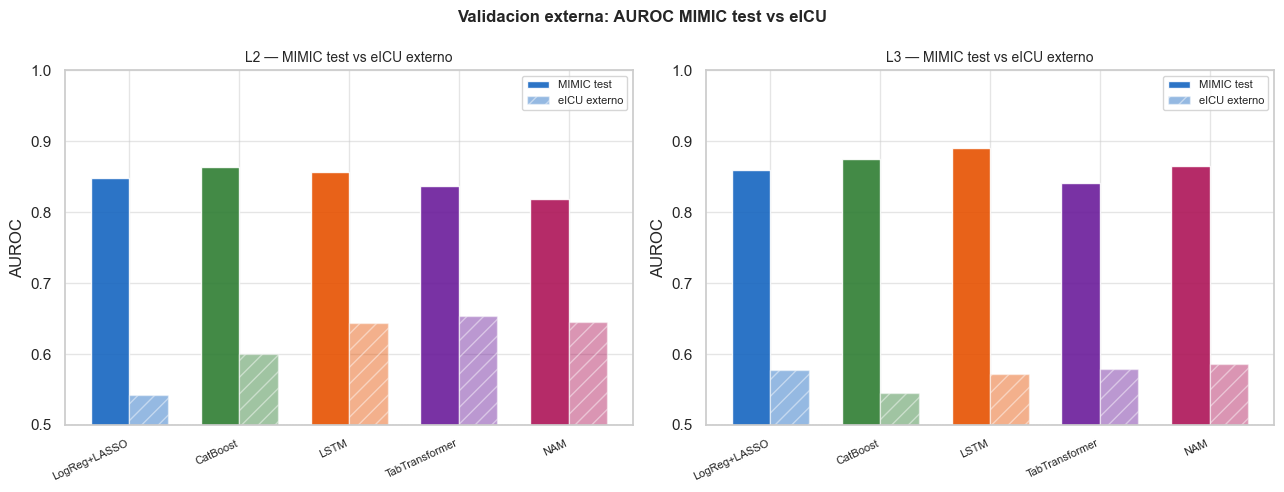

Figura guardada: C:\Users\cuent\Documents\UAX\TFM\TFM\reports\figures\eicu_auroc_comparison.png


In [19]:
# Se cargan las métricas del test MIMIC para comparación directa
mimic_metrics = pd.read_csv(_root / 'reports/tables/test_metrics.csv')

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#AD1457']

for ax, t in zip(axes, TARGETS):
    mimic_sub = mimic_metrics[mimic_metrics.Target == t].set_index('Modelo')
    eicu_sub  = df_metrics_eicu[df_metrics_eicu.Target == t].set_index('Modelo')

    x  = range(len(MODELS))
    w  = 0.35
    ax.bar([xi - w/2 for xi in x],
           [mimic_sub.loc[LABELS[m], 'AUROC'] for m in MODELS],
           width=w, label='MIMIC test', color=colors, alpha=0.9)
    ax.bar([xi + w/2 for xi in x],
           [eicu_sub.loc[LABELS[m], 'AUROC'] for m in MODELS],
           width=w, label='eICU externo', color=colors, alpha=0.45, hatch='//')

    ax.set_xticks(list(x))
    ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel('AUROC')
    ax.set_title(f'{t} — MIMIC test vs eICU externo', fontsize=10)
    ax.legend(fontsize=8)
    ax.axhline(0.5, color='gray', lw=0.8, ls=':')

plt.suptitle('Validacion externa: AUROC MIMIC test vs eICU', fontsize=12, fontweight='bold')
plt.tight_layout()
fig_path = _root / 'reports/figures/eicu_auroc_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {fig_path}')

**Interpretación — `eicu_auroc_comparison.png`**

La validación externa sobre eICU-CRD confirma una caída sistemática del AUROC de 0,20–0,33 puntos respecto al test interno de MIMIC-IV-ED en todos los modelos y desenlaces. En L2, el AUROC interno oscila entre 0,82 y 0,87, mientras que en eICU cae a 0,57–0,63. En L3, la caída es aún más pronunciada (de 0,86–0,89 a 0,55–0,58). Este desplazamiento de dominio se atribuye a tres factores: (1) diferencia de severidad entre pacientes de UCI (eICU) y urgencias generales (MIMIC), (2) diferencia de prevalencia de los desenlaces, y (3) ausencia del nivel ESI en eICU (sustituido por el APache score como proxy), que es la variable de mayor importancia SHAP. La LSTM muestra la mayor caída en L3, probablemente porque las secuencias de vitalsign en eICU tienen una densidad temporal distinta a la del entrenamiento.

## 9. Guardar predicciones y métricas

Serialización de `predictions_eicu.parquet` y `eicu_metrics.csv` en los directorios estándar del proyecto para su uso en comparaciones post-hoc y en el manuscrito.

In [20]:
eicu_preds.to_parquet(PROCESSED / 'predictions_eicu.parquet', index=False)
df_metrics_eicu.to_csv(_root / 'reports/tables/eicu_metrics.csv', index=False)

print(f'predictions_eicu.parquet — shape {eicu_preds.shape}')
print(f'eicu_metrics.csv guardado')
df_metrics_eicu.round(4)

predictions_eicu.parquet — shape (89594, 15)
eicu_metrics.csv guardado


,Target,Modelo,AUROC,AUPRC,Brier,Prev
0,L2,LogReg+LASSO,0.5427,0.1299,0.3332,0.0858
1,L2,CatBoost,0.6000,0.1414,0.2242,0.0858
2,L2,LSTM,0.6432,0.1802,0.2564,0.0858
3,L2,TabTransformer,0.6530,0.1846,0.7210,0.0858
4,L2,NAM,0.6451,0.1849,0.4121,0.0858
5,L3,LogReg+LASSO,0.5769,0.2677,0.4005,0.1912
6,L3,CatBoost,0.5444,0.2194,0.6524,0.1912
7,L3,LSTM,0.5716,0.2569,0.2997,0.1912
8,L3,TabTransformer,0.5788,0.2580,0.6037,0.1912
9,L3,NAM,0.5858,0.2778,0.3117,0.1912
